# 02 — How sure are we, and which differences are real?

Two tools from statistics:

- **Confidence interval** — a mean from one snapshot is an estimate; the
  interval says how far off it could plausibly be.
- **Hypothesis test** — two groups always differ a little by chance; a test
  says whether the gap is bigger than chance would produce.

With ~7,000 listings almost any gap is "statistically significant", so each
comparison also reports the gap **in euros** — the number that matters.

In [8]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src import config as cfg
from src import cleaning

sns.set_theme(style="whitegrid", palette="colorblind")
np.random.seed(cfg.SEED)

In [9]:
df = pd.read_csv(cfg.CLEAN_FILE)
df["price"].describe().round(1)

count    6995.0
mean      181.7
std       117.0
min         9.0
25%       103.0
50%       153.0
75%       225.0
max      1000.0
Name: price, dtype: float64

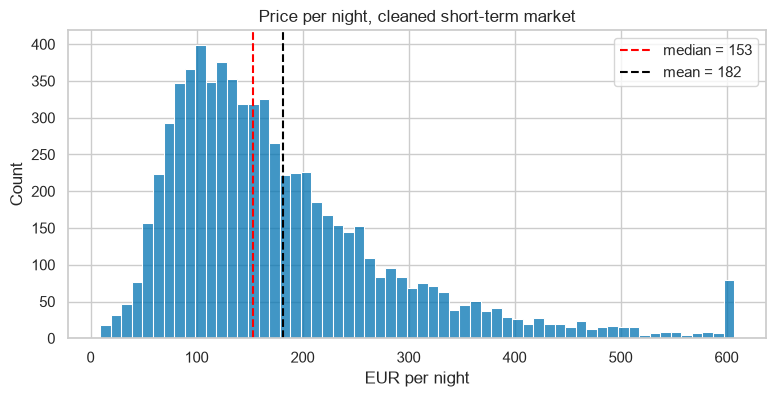

In [10]:
# One chart: the price distribution (top 1% clipped so the axis is readable)
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df["price"].clip(upper=df["price"].quantile(0.99)), bins=60, ax=ax)
ax.axvline(df["price"].median(), color="red", ls="--",
           label=f"median = {df['price'].median():.0f}")
ax.axvline(df["price"].mean(), color="black", ls="--",
           label=f"mean = {df['price'].mean():.0f}")
ax.legend(); ax.set_xlabel("EUR per night")
ax.set_title("Price per night, cleaned short-term market")
fig.savefig(cfg.FIGURES_DIR / "02_price_distribution.png", dpi=150, bbox_inches="tight")

The mean sits well above the median because a small number of expensive
listings pull it up (right-skewed data). For "what does a typical listing
cost?", the **median** is the honest answer; the mean is for revenue math.

## Confidence interval for the mean price — two ways

**Formula:** mean ± t · (std / √n).
**Bootstrap:** resample the data with replacement 5,000 times, take each
sample's mean, read the middle 95%. No formula, no assumptions — a good
cross-check.

In [11]:
price = df["price"]
n = len(price)

# --- formula ---
mean = price.mean()
se = price.std() / np.sqrt(n)                      # standard error
lo_f, hi_f = stats.t.interval(0.95, n - 1, loc=mean, scale=se)

# --- bootstrap ---
boot_means = []
for _ in range(5000):
    sample = price.sample(n, replace=True)
    boot_means.append(sample.mean())
lo_b, hi_b = np.percentile(boot_means, [2.5, 97.5])

print(f"mean price: {mean:.1f} EUR")
print(f"formula   95% CI: [{lo_f:.1f}, {hi_f:.1f}]")
print(f"bootstrap 95% CI: [{lo_b:.1f}, {hi_b:.1f}]")

mean price: 181.7 EUR
formula   95% CI: [178.9, 184.4]
bootstrap 95% CI: [179.0, 184.4]


The two intervals agree closely — with 7,000 listings the formula's
assumptions hold fine. The value of computing both: if they *disagreed*, we
would trust the bootstrap, because it makes no assumptions.

## Test 1 — Do entire homes cost more than private rooms?

- **H0:** the mean price is the same for both
- **Test:** two-sample t-test (Welch's version — does not assume the two
  groups have equal spread), alpha = 0.05

In [12]:
entire = df.loc[df["room_type"] == "Entire home/apt", "price"]
private = df.loc[df["room_type"] == "Private room", "price"]

t_stat, p_value = stats.ttest_ind(entire, private, equal_var=False)

print(f"entire homes  : n={len(entire):,}, mean={entire.mean():.0f} EUR")
print(f"private rooms : n={len(private):,}, mean={private.mean():.0f} EUR")
print(f"difference    : {entire.mean() - private.mean():.0f} EUR per night")
print(f"p-value       : {p_value:.2e}")

entire homes  : n=4,865, mean=210 EUR
private rooms : n=1,964, mean=115 EUR
difference    : 95 EUR per night
p-value       : 6.43e-301


No surprise that entire homes cost more — the point is the **size**: about
€95 per night. This comparison also works as a sanity check: if the method
missed *this*, something would be wrong.

## Test 2 — Do central districts cost more?

Central = Mitte, Friedrichshain-Kreuzberg, Pankow, Neukölln (defined in
`src/config.py`).

In [13]:
central = df.loc[df["is_central"], "price"]
outer = df.loc[~df["is_central"], "price"]

t_stat, p_value = stats.ttest_ind(central, outer, equal_var=False)

print(f"central : n={len(central):,}, mean={central.mean():.0f} EUR")
print(f"outer   : n={len(outer):,}, mean={outer.mean():.0f} EUR")
print(f"difference : {central.mean() - outer.mean():.0f} EUR per night "
      f"(about {central.mean()/outer.mean()-1:.0%})")
print(f"p-value    : {p_value:.2e}")

central : n=4,655, mean=191 EUR
outer   : n=2,340, mean=164 EUR
difference : 27 EUR per night (about 17%)
p-value    : 6.26e-20


Real, but much smaller than the room-type gap. And there is a catch: central
districts also have **more entire homes**, which are expensive anywhere. How
much of this gap is really location? That is what the regression in
notebook 03 answers.

## Test 3 — The licence split, tested properly

Notebook 01 showed ~98% of short-term listings display a licence vs ~7% of
long-stay ones. Here the same comparison gets a formal test. Because this is
a **rate** (yes/no per listing), the right tool is a **two-proportion
z-test**, not a t-test.

In [14]:
raw = cleaning.add_columns(cleaning.load_listings())

short = raw[raw["is_short_term"]]
long_ = raw[~raw["is_short_term"]]

p1, n1 = short["has_licence"].mean(), len(short)
p2, n2 = long_["has_licence"].mean(), len(long_)

# z-test for two proportions
p_pool = (short["has_licence"].sum() + long_["has_licence"].sum()) / (n1 + n2)
se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
z = (p1 - p2) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

print(f"short-term: {p1:.1%} of {n1:,} listings show a licence")
print(f"long-stay : {p2:.1%} of {n2:,} listings")
print(f"difference: {(p1 - p2) * 100:.1f} percentage points, p-value = {p_value:.2e}")

short-term: 97.9% of 8,680 listings show a licence
long-stay : 7.5% of 4,175 listings
difference: 90.4 percentage points, p-value = 0.00e+00


**Careful with the interpretation:** a missing licence means Airbnb
*displayed* no number — not that the listing is illegal. Long-stay listings
do not need one, and Berlin had
[paused issuing new numbers](https://www.berlin.de/sen/wohnen/rechtliches/zweckentfremdungsverbot/)
while implementing the new EU rules.

## What I found

1. Median __ EUR, mean __ EUR; 95% CI for the mean: [__, __] — formula and
   bootstrap agree.
2. Entire homes cost __ EUR more than private rooms (p < __).
3. Central districts cost __ EUR more (~__%), but part of that could be the
   room-type mix — notebook 03 separates the two.
4. Licence display: __% vs __% (p < __) — the regulation is visible in the
   data.